In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Investigation — Tyler Hann

## 1. Research Question and Hypothesis
Research Question: Is there a relationship between malaria cases and access to essential health services across countries?

Hypothesis: Countries with better access to basic public services will have lower numbers of malaria cases overall

## 2. Data Source and Integrity
the dataset was cleaned to make the data easier to analyse. Empty rows were removed, and missing values were checked. Duplicated rows were also searched for to make sure no data was repeated.

The country names were formatted by removing extra spaces and changing text to lowercase so the data is consistent. Statistics were then used to check for outliers in the malaria cases data. These steps helped improve reliability of the dataset before making graphs and analysing results.

## 3. Exploratory Analysis - Tyler Hann responses.
The dataset was first cleaned and organised before analysis began. 
Empty rows were removed so they would not affect calculations, and missing values and duplicate entries were checked to improve the accuracy of the data. 
Country names were also reformatted to lowercase and stripped of extra spaces so the same country would not appear as multiple entries. After cleaning, the malaria cases data was explored using summary statistics to identify the spread of values and possible outliers. 

Several water and sanitation columns were then grouped together to create an average “health access” score, which made it easier to compare overall access to basic services with malaria cases. Finally, the data was grouped by year to calculate yearly averages and observe overall trends over time.

It was expected that countries with better access to general services overall would have lower malaria case numbers. However, the relationship was not as strong/direct as I wanted it to be, which was somewhat surprising. This may be because malaria is influenced by many other factors and not just sanitisation, such as climate, mosquito populations, healthcare access, poverty, and disease prevention programs. As a follow-up, more analysis could compare individual variables separately, investigate specific countries/areas, or create graphs and scatter plots to better visualise any trends or correlations in the data.

## 4. Analysis and Visualisation
[Week 3]

## 5. Hypothesis Assessment
[Week 3 — placeholder, complete in W3L2]

## 6. Recommendation
[Week 4 — placeholder, complete in W4L2]

## 7. Reflection
[Week 4]

count    5.500000e+02
mean     1.068330e+06
std      2.192802e+06
min      0.000000e+00
25%      2.211750e+03
50%      1.130260e+05
75%      1.154808e+06
max      1.682113e+07
Name: Malaria cases reported, dtype: float64


,Health_access_avg,Malaria cases reported
Year,,
2007,46.44,202046.82
2008,47.10,190167.48
2009,47.76,288292.32
2010,48.42,443695.20
2011,48.61,460057.30
2012,49.23,794384.42
2013,49.84,943499.18
2014,50.43,1540576.28
2015,51.03,1859370.52


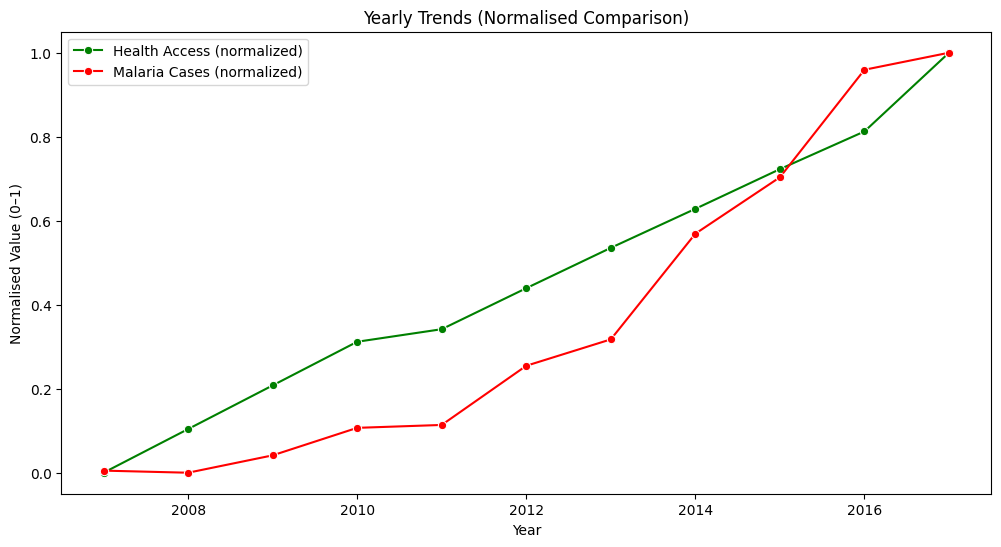

In [12]:
# Example: Read Excel file/Remove deleted data

df = pd.read_excel('DatasetAfricaMalaria.xlsx')

# Remove Rows with missing values
df = df.dropna(how='all')

# See missing values
df.isnull().sum()

# See Duplicates and remove them
df[df.duplicated(keep=False)]

# Formatting/categorical data
df['Country Name'] = df['Country Name'].astype(str).str.strip().str.lower()
df['Country Name'].value_counts().head(10)

# Outliers
print(df['Malaria cases reported'].describe())

# Creating a "Storage" for all health columns/data
health_cols = [
    'People using safely managed drinking water services (% of population)',
    'People using safely managed sanitation services (% of population)',
    'People using at least basic drinking water services (% of population)',
    'People using at least basic sanitation services (% of population)'
]

# Average health-access score
df['Health_access_avg'] = df[health_cols].mean(axis=1)

# Yearly mean table (rounded)
yearly = df.groupby('Year')[['Health_access_avg','Malaria cases reported']].mean().round(2)

# Styled display: green = better access; red = higher cases
display(yearly)

yearly_norm = yearly.copy()

yearly_norm['Health_access_avg'] = (
    yearly['Health_access_avg'] - yearly['Health_access_avg'].min()
) / (yearly['Health_access_avg'].max() - yearly['Health_access_avg'].min()
)

yearly_norm['Malaria cases reported'] = (
    yearly_norm['Malaria cases reported'] - yearly_norm['Malaria cases reported'].min()
) / (
    yearly_norm['Malaria cases reported'].max() - yearly_norm['Malaria cases reported'].min()
)
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_norm,
    x=yearly_norm.index,
    y='Health_access_avg',
    marker='o',
    label='Health Access (normalized)',
    color='green'
)

sns.lineplot(
    data=yearly_norm,
    x=yearly_norm.index,
    y='Malaria cases reported',
    marker='o',
    label='Malaria Cases (normalized)',
    color='red'
)

plt.title('Yearly Trends (Normalised Comparison)')
plt.xlabel('Year')
plt.ylabel('Normalised Value (0–1)')
plt.legend()
plt.show()

/Users/tyler.hann/Downloads/Data-analytics-main/Untitled/Data-Analytics-Investigation/.venv/lib/python3.14/site-packages/matplotlib/transforms.py:352: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


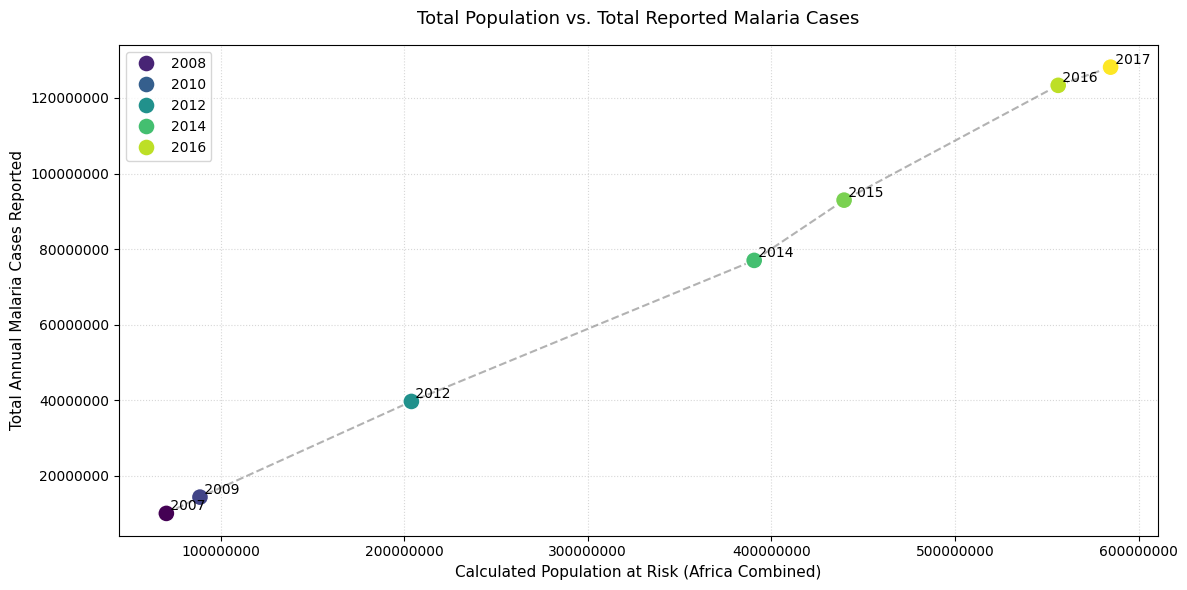

In [13]:

df['Population_At_Risk'] = (
    df['Malaria cases reported'] / df['Incidence of malaria (per 1,000 population at risk)']
) * 1000

yearly_totals = df.groupby('Year')[['Population_At_Risk', 'Malaria cases reported']].sum().reset_index()

yearly_totals = yearly_totals.dropna().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=yearly_totals,
    x='Population_At_Risk',
    y='Malaria cases reported',
    hue='Year',
    palette='viridis',
    s=150,
    ax=ax,
    zorder=3
)

sns.lineplot(
    data=yearly_totals,
    x='Population_At_Risk',
    y='Malaria cases reported',
    color='gray',
    linestyle='--',
    alpha=0.6,
    ax=ax,
    zorder=2
)

for idx, row in yearly_totals.iterrows():
    ax.text(
        row['Population_At_Risk'], 
        row['Malaria cases reported'], 
        f" {int(row['Year'])}", 
        fontsize=10, 
        verticalalignment='bottom',
        horizontalalignment='left'
    )


ax.set_title('Total Population vs. Total Reported Malaria Cases', fontsize=13, pad=15)
ax.set_xlabel('Calculated Population at Risk (Africa Combined)', fontsize=11)
ax.set_ylabel('Total Annual Malaria Cases Reported', fontsize=11)

ax.ticklabel_format(style='plain', axis='both')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

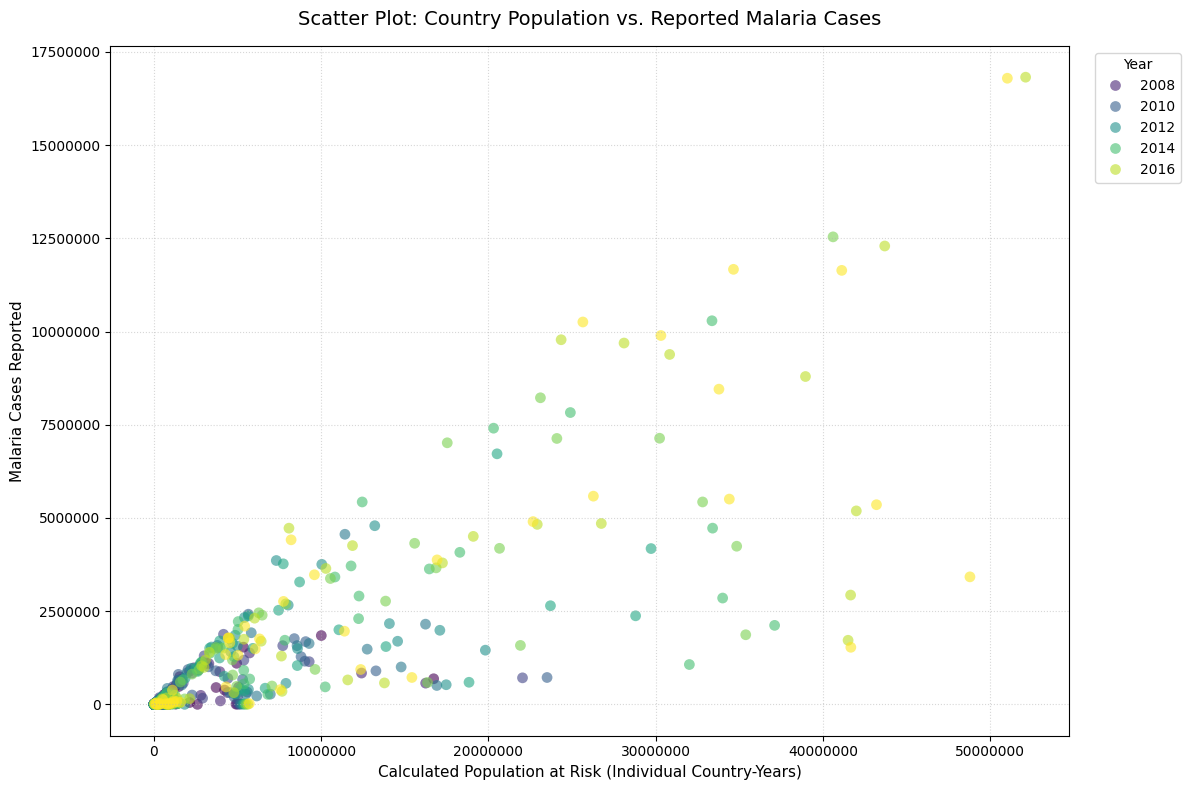

In [ ]:
df['Population_At_Risk'] = (
    df['Malaria cases reported'] / df['Incidence of malaria (per 1,000 population at risk)']
) * 1000

df_scatter = df.dropna(subset=['Population_At_Risk', 'Malaria cases reported']).copy()

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_scatter,
    x='Population_At_Risk',
    y='Malaria cases reported',
    hue='Year',
    palette='viridis', 
    s=60,
    alpha=0.6,
    edgecolor='none',
    ax=ax
)

ax.set_title('Scatter Plot: Country Population vs. Reported Malaria Cases', fontsize=14, pad=15)
ax.set_xlabel('Calculated Population at Risk (Individual Country-Years)', fontsize=11)
ax.set_ylabel('Malaria Cases Reported', fontsize=11)

ax.ticklabel_format(style='plain', axis='both')
ax.grid(True, linestyle=':', alpha=0.5)

ax.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()